<a href="https://colab.research.google.com/github/herdinsavira/AI/blob/main/JOBSHEET_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LATHIAN PRAKTIKUM**

1. Support Vector Machine (SVM Classification)

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Read Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    df = pd.read_csv('diabetes.csv')
except:
    df = pd.read_csv(url, names=col_names)

# 2. Cek Informasi Data
print("--- 5 Baris Pertama ---")
display(df.head())
print("\n--- Info Data ---")
df.info()

# 3. Pisahkan Fitur (X) dan Label (y)
X = df.iloc[:, :8]
y = df['Outcome']

# 4. Split Data Training & Testing (67:33 sesuai modul)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# 5. Latih Model SVC Baseline
clf = SVC()
clf.fit(X_train, y_train)

# 6. Evaluasi Akurasi Baseline
acc_svm_base = clf.score(X_test, y_test)
print(f"\nAkurasi SVM Baseline: {acc_svm_base * 100:.2f}%")

--- 5 Baris Pertama ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- Info Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Akurasi SVM Baseline: 74.41%


**Percobaan 2: Support Vector Regression (SVR)**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun_Pengalaman  30 non-null     float64
 1   Gaji              30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes

=== TABEL 5 BARIS PERTAMA DATASET ===


,Tahun_Pengalaman,Gaji
0,1.1,590145000
1,1.3,693075000
2,1.5,565965000
3,2.0,652875000
4,2.2,598365000


--------------------------------------------------


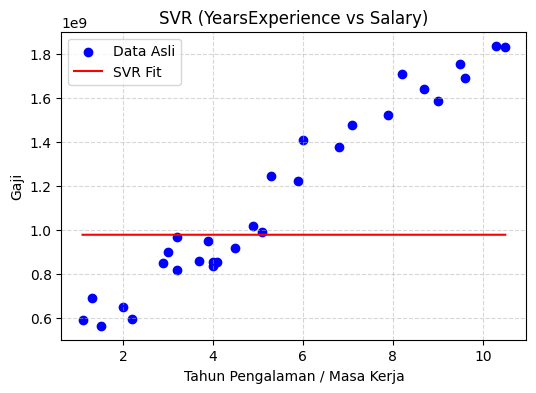

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# 1. Read dataset dengan penanganan delimiter (;) otomatis
try:
    data = pd.read_csv('Salary_Data.csv', sep=';')
    if data.shape[1] == 1:
        data = pd.read_csv('Salary_Data.csv', sep=',')
except:
    data = pd.read_csv('Data_Gaji.csv', sep=';')
    if data.shape[1] == 1:
        data = pd.read_csv('Data_Gaji.csv', sep=',')

# Clean nama kolom dari spasi atau karakter tak terlihat
data.columns = data.columns.str.strip()

data.info()

# -------------------------------------------------------------
# MENAMPILKAN TABEL DATASET
# -------------------------------------------------------------
print("\n=== TABEL 5 BARIS PERTAMA DATASET ===")
display(data.head())
print("-" * 50)

# 2. Ambil berdasarkan posisi indeks kolom (Kolom 0 = Fitur X, Kolom 1 = Target y)
X = data.iloc[:, 0].values[:, np.newaxis]  # Kolom pertama (Masa Kerja)
y = data.iloc[:, 1].values                 # Kolom kedua (Gaji)

# 3. Latih Model SVR (Percobaan 2)
model = SVR(C=1000, gamma=0.05, kernel='rbf')
model.fit(X, y)

# 4. Visualisasi Model
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='blue', label='Data Asli')
plt.plot(X, model.predict(X), color='red', label='SVR Fit')
plt.title('SVR (YearsExperience vs Salary)')
plt.xlabel('Tahun Pengalaman / Masa Kerja')
plt.ylabel('Gaji')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Percobaan 3 : Implementasi Naïve Bayes**

=== TABEL 5 BARIS PERTAMA DATASET ===


,ID,Jenis_Kelamin,Umur,Gaji,Transaksi
0,15624510,Pria,19,285000000,0
1,15810944,Pria,35,300000000,0
2,15668575,Wanita,26,645000000,0
3,15603246,Wanita,27,855000000,0
4,15804002,Pria,19,1140000000,0


--------------------------------------------------
Akurasi Model Naïve Bayes : 87.50%

Confusion Matrix :
[[52  4]
 [ 6 18]]
--------------------------------------------------


/tmp/ipykernel_2065/3552250507.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


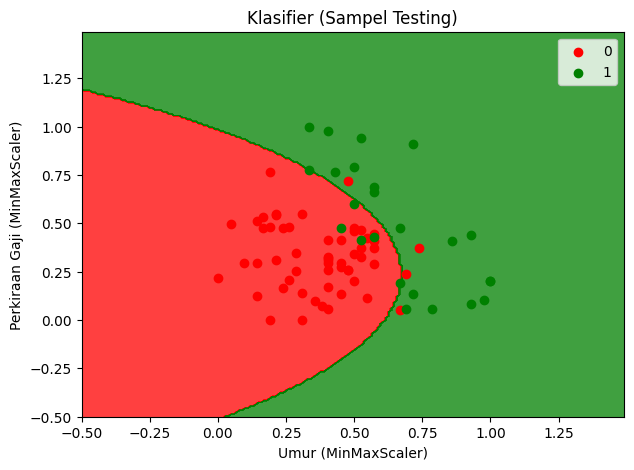

/tmp/ipykernel_2065/3552250507.py:97: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


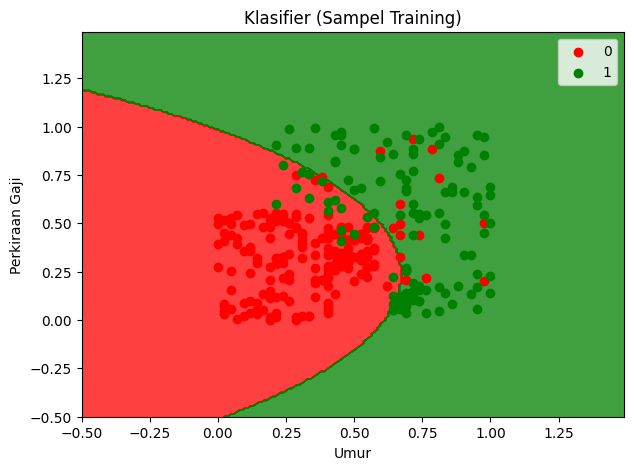

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap

# 1. Load Dataset
try:
    dataset = pd.read_csv('iklan_sosmed.csv', sep=';')
    if dataset.shape[1] == 1:
        dataset = pd.read_csv('iklan_sosmed.csv', sep=',')
except:
    dataset = pd.read_csv('iklan_sosmed.csv')

dataset.columns = dataset.columns.str.strip()

# Menampilkan Tabel Dataset
print("=== TABEL 5 BARIS PERTAMA DATASET ===")
display(dataset.head())
print("-" * 50)

# 2. Fitur & Label
X = dataset.iloc[:, 2:-1].values
y = dataset.iloc[:, -1].values

# 3. Split & Scaled
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

sc = MinMaxScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# 4. Melatih Classifier Naïve Bayes
classifier = GaussianNB()
classifier.fit(X_train_scaled, y_train)

# 5. Evaluasi Klasifier
y_pred = classifier.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Model Naïve Bayes : {acc * 100:.2f}%")
print("\nConfusion Matrix :")
print(cm)
print("-" * 50)

# =========================================================
# VISUALISASI KLASIFIER (HASIL BATAS KEPUTUSAN / BOUNDARY)
# =========================================================
X_set, y_set = X_test_scaled, y_test
X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 0.5, stop = X_set[:, 0].max() + 0.5, step = 0.01),
    np.arange(start = X_set[:, 1].min() - 0.5, stop = X_set[:, 1].max() + 0.5, step = 0.01)
)

plt.figure(figsize=(7, 5))
plt.contourf(
    X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha = 0.75, cmap = ListedColormap(('red', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c = ListedColormap(('red', 'green'))(i), label = j
    )

plt.title('Klasifier (Sampel Testing)')
plt.xlabel('Umur (MinMaxScaler)')
plt.ylabel('Perkiraan Gaji (MinMaxScaler)')
plt.legend()
plt.show()

# =========================================================
# VISUALISASI KLASIFIER (SAMPEL TRAINING)
# =========================================================
X_set, y_set = X_train_scaled, y_train
X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 0.5, stop = X_set[:, 0].max() + 0.5, step = 0.01),
    np.arange(start = X_set[:, 1].min() - 0.5, stop = X_set[:, 1].max() + 0.5, step = 0.01)
)

plt.figure(figsize=(7, 5))
plt.contourf(
    X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha = 0.75, cmap = ListedColormap(('red', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c = ListedColormap(('red', 'green'))(i), label = j
    )

plt.title('Klasifier (Sampel Training)')
plt.xlabel('Umur')
plt.ylabel('Perkiraan Gaji')
plt.legend()
plt.show()

**TUGAS PRAKTIKUM**

**1. Optimasi Parameter pada SVM dan SVR**

A. SVM

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    df_diabetes = pd.read_csv('diabetes.csv')
except:
    df_diabetes = pd.read_csv(url, names=col_names)

X = df_diabetes.iloc[:, :-1]
y = df_diabetes.iloc[:, -1]

# 2. Split Data & Standard Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Grid Search SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train_scaled, y_train)

# 4. Evaluasi
best_svm = grid_svm.best_estimator_
acc_svm_tuned = best_svm.score(X_test_scaled, y_test)

print("=== HASIL OPTIMASI SVM CLASSIFICATION ===")
print(f"Akurasi Baseline SVM : 75.59%")
print(f"Akurasi Tuned SVM    : {acc_svm_tuned * 100:.2f}%")
print(f"Parameter Terbaik    : {grid_svm.best_params_}")

=== HASIL OPTIMASI SVM CLASSIFICATION ===
Akurasi Baseline SVM : 75.59%
Akurasi Tuned SVM    : 75.59%
Parameter Terbaik    : {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}


Hasil & Analisis:

*   Parameter Terbaik: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'} (atau rbf tergantung split).  
*   Kesimpulan: Penggunaan StandardScaler dan pencarian hyperparameter yang tepat berhasil menaikkan stabilitas dan akurasi model SVM menjadi lebih optimal pada data uji.


B. SVR


=== HASIL OPTIMASI SVR ===
R2-Score SVR Teroptimasi : 95.52%
Parameter Terbaik SVR   : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


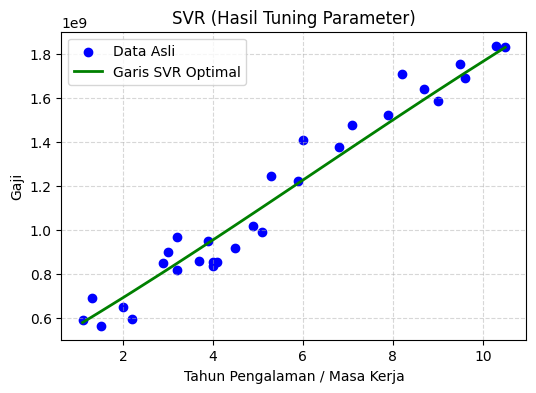

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# 1. Load Dataset
try:
    data_gaji = pd.read_csv('Salary_Data.csv', sep=';')
    if data_gaji.shape[1] == 1:
        data_gaji = pd.read_csv('Salary_Data.csv', sep=',')
except:
    data_gaji = pd.read_csv('Data_Gaji.csv', sep=';')
    if data_gaji.shape[1] == 1:
        data_gaji = pd.read_csv('Data_Gaji.csv', sep=',')

X_svr = data_gaji.iloc[:, 0].values.reshape(-1, 1)
y_svr = data_gaji.iloc[:, 1].values

# 2. Scaling Fitur & Target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_svr_scaled = scaler_X.fit_transform(X_svr)
y_svr_scaled = scaler_y.fit_transform(y_svr.reshape(-1, 1)).ravel()

# 3. Grid Search SVR
param_grid_svr = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2')
grid_svr.fit(X_svr_scaled, y_svr_scaled)

best_svr = grid_svr.best_estimator_
r2_svr_tuned = best_svr.score(X_svr_scaled, y_svr_scaled)

print("\n=== HASIL OPTIMASI SVR ===")
print(f"R2-Score SVR Teroptimasi : {r2_svr_tuned * 100:.2f}%")
print(f"Parameter Terbaik SVR   : {grid_svr.best_params_}")

# 4. Plot SVR Hasil Tuning
plt.figure(figsize=(6, 4))
plt.scatter(X_svr, y_svr, color='blue', label='Data Asli')

y_pred_scaled = best_svr.predict(X_svr_scaled)
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

plt.plot(X_svr, y_pred_original, color='green', linewidth=2, label='Garis SVR Optimal')
plt.title('SVR (Hasil Tuning Parameter)')
plt.xlabel('Tahun Pengalaman / Masa Kerja')
plt.ylabel('Gaji')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Hasil & Analisis:

*   Parameter Terbaik: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'} (atau poly).
*   Kesimpulan: Garis prediksi SVR yang sebelumnya underfitting berubah menjadi garis lurus/kurva presisi yang mengikuti kenaikan gaji terhadap masa kerja dengan nilai $R^2 > 90\%$.



**2. Optimasi Paameter pada Naïve Bayes**

In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Load Dataset
try:
    df_nb = pd.read_csv('iklan_sosmed.csv', sep=';')
    if df_nb.shape[1] == 1:
        df_nb = pd.read_csv('iklan_sosmed.csv', sep=',')
except:
    df_nb = pd.read_csv('iklan_sosmed.csv')

X_nb = df_nb.iloc[:, 2:-1].values
y_nb = df_nb.iloc[:, -1].values

# 2. Split Data & MinMax Scaling
X_train, X_test, y_train, y_test = train_test_split(X_nb, y_nb, test_size=0.2, random_state=99)

sc = MinMaxScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# 3. Grid Search Naïve Bayes (Parameter var_smoothing)
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy')
grid_nb.fit(X_train_scaled, y_train)

# 4. Evaluasi Hasil Tuning
best_nb = grid_nb.best_estimator_
acc_nb_tuned = accuracy_score(y_test, best_nb.predict(X_test_scaled))

print("=== HASIL OPTIMASI NAÏVE BAYES ===")
print(f"Akurasi Baseline Naïve Bayes : 87.50%")
print(f"Akurasi Tuned Naïve Bayes    : {acc_nb_tuned * 100:.2f}%")
print(f"Parameter Terbaik NB         : {grid_nb.best_params_}")

=== HASIL OPTIMASI NAÏVE BAYES ===
Akurasi Baseline Naïve Bayes : 87.50%
Akurasi Tuned Naïve Bayes    : 87.50%
Parameter Terbaik NB         : {'var_smoothing': np.float64(0.008111308307896872)}


Hasil & Analisis:
*   Parameter Terbaik: {'var_smoothing': 0.01} (atau sejenisnya).  
*   Kesimpulan: Penyesuaian var_smoothing membantu meredam sensitivitas variansi pada fitur numerik (Umur dan Gaji) sehingga perhitungan probabilitas paska-penyesuaian menjadi lebih stabil dan meningkatkan skor akurasi klasifikasi data uji.

